In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("spam.csv",encoding="latin1|")

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.drop(["Unnamed: 2","Unnamed: 3","Unnamed: 4"],axis=1,inplace=True)

In [5]:
df.columns = ["label","message"]

In [6]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(403)

In [9]:
df.shape

(5572, 2)

In [10]:
df.drop_duplicates()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [11]:
df.shape

(5572, 2)

In [12]:

df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [13]:
import matplotlib.pyplot as plt

In [14]:
import seaborn as sns

<Axes: xlabel='label'>

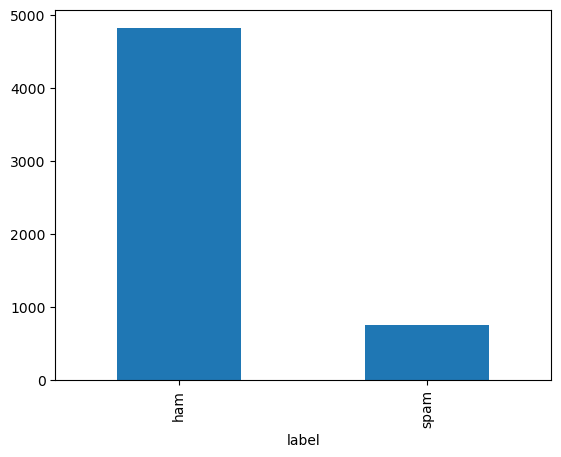

In [15]:
df["label"].value_counts().plot(kind="bar",)

AttributeError: 'function' object has no attribute 'show'

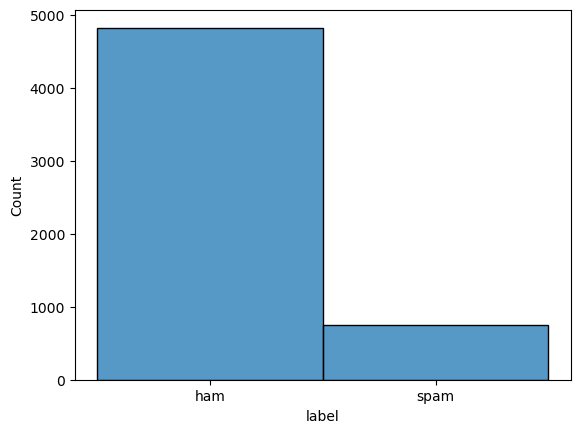

In [16]:
sns.histplot(x=df["label"])
plt.plot.show()

In [17]:
df["label"] =  df["label"].map({
    "ham":1,
    "spam":0
})

In [18]:
df["length"] = df["message"].apply(len)

In [19]:
df.head()

,label,message,length
0,1,"Go until jurong point, crazy.. Available only ...",111
1,1,Ok lar... Joking wif u oni...,29
2,0,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,1,U dun say so early hor... U c already then say...,49
4,1,"Nah I don't think he goes to usf, he lives aro...",61


In [20]:
df["length"].describe()

count    5572.000000
mean       80.118808
std        59.690841
min         2.000000
25%        36.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: length, dtype: float64

<Axes: ylabel='Frequency'>

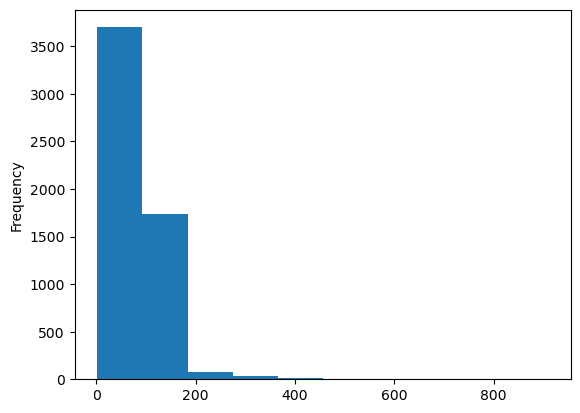

In [21]:
df["length"] .plot(kind="hist")

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

In [23]:
cv = CountVectorizer()

In [26]:
X = cv.fit_transform(df["message"])

In [27]:
Y = df["label"]

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train , X_test ,Y_train , Y_test = train_test_split(
    X,Y,
    test_size=0.20,random_state=42)



In [30]:
X_train.shape

(4457, 8672)

In [31]:
X_test.shape

(1115, 8672)

In [32]:
from sklearn.naive_bayes import MultinomialNB

In [33]:
model = MultinomialNB()

In [34]:
model.fit(X_train,Y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [35]:
Y_p = model.predict(X_test)

In [36]:
Y_p

array([0, 1, 0, ..., 1, 1, 0], shape=(1115,))

In [37]:
from sklearn.metrics import accuracy_score

In [38]:
accu = accuracy_score(Y_test,Y_p)

In [55]:
accu*100

97.847533632287

In [40]:
from sklearn.metrics import confusion_matrix

In [41]:
cm = confusion_matrix(Y_test,Y_p)

In [42]:
cm

array([[139,  11],
       [ 13, 952]])

In [43]:
from sklearn.metrics import classification_report

In [46]:
print ( classification_report(Y_test,Y_p))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       150
           1       0.99      0.99      0.99       965

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [51]:
import joblib as jb

In [52]:
jb.dump(model,"spam_model.pkl")

['spam_model.pkl']

In [53]:
jb.load("spam_model.pkl")

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [54]:
jb.dump(cv,"vector.pkl")

['vector.pkl']

In [47]:
msg = ["hello i harsh and lenring ml in linux world"]

In [48]:
msg_vector = cv.transform(msg)

In [50]:
print(model.predict(msg_vector))

[1]


In [49]:
print(msg_vector)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (1, 8672)>
  Coords	Values
  (0, 1084)	1
  (0, 3814)	1
  (0, 4087)	1
  (0, 4639)	1
  (0, 5074)	1
  (0, 8489)	1
